<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/OB_0306_%EC%84%B8%EC%85%98_%EB%AA%A8%EB%8D%B8%ED%9B%88%EB%A0%A8_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **모델 훈련 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch04 연습문제 1, 5, 9, 10
- 개념 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

### **1. 수백만 개의 특성을 가진 훈련 세트에서는 어떤 선형 회귀 알고리즘을 사용할 수 있을까요?**
___


- 수백만 개의 특성을 가진 훈련 세트의 문제 = 너무 많은 피처
- **확률적 경사 하강법, 미니배치 경사 하강법** 사용 가능
  - Gradient Descent 기반 알고리즘
- 훈련 세트가 메모리 크기에 맞으면 배치 경사 하강법도 가능
- 정규 방정식이나 SVD 방법은 계산 복잡도가 특성 개수에 따라 매우 빠르게 증가하기 때문에 사용할 수 없음

### **2. 배치 경사 하강법을 사용하고 에포크마다 검증 오차를 그래프로 나타내봤습니다. 검증 오차가 일정하게 상승되고 있다면 어떤 일이 일어나고 있는 걸까요? 이 문제를 어떻게 해결할 수 있나요?**
___

배치 경사 하강법에서 검증 오차가 계속 증가하는 이유

1. 학습률이 너무 높은 경우
- 학습률이 너무 크면 최적점 주변세어 진동 또는 발산함
- 해결방법 : learning rate 감소

2. 과적합
- 모델이 훈련 데이터에만 맞춰진다면,
  - train error ↓, validation error ↑
- 해결방법 : early stopping, 정규화



---



< Bias–Variance 그래프 >

1. Bias = 모델이 너무 단순
- train error ↑, validation error ↑

2. Variance = 모델이 너무 복잡
- train error ↓, validation error ↑

### **3. 릿지 회귀를 사용했을 때 훈련 오차가 검증 오차가 거의 비슷하고 둘 다 높았습니다. 이 모델에는 높은 편향이 문제인가요, 아니면 높은 분산이 문제인가요? 규제 하이퍼파라미터 $\alpha$를 증가시켜야 할까요 아니면 줄여야 할까요?**
___

상황 : train error 높음, validation error 높음, 둘이 거의 동일

즉, 모델이 데이터 패턴을 제대로 학습하지 못한 상태 = 높은 편향 상태

| 상황                | 의미            |
| ----------------- | ------------- |
| train 낮음 / val 높음 | high variance |
| train 높음 / val 높음 | high bias     |


- 릿지 회귀에서  α 는 가중치 패널티 강도를 조절하는 규제 하이퍼 파라미터
  - 크면
    - 패널티 강함 > 가중치 작아짐 > 모델 단순 > bias 증가
  - 작으면
    - 패널티 약함 > 가중치 커짐 > 모델 복잡 > bias 감소

- 가중치가 크다는 것은 데이터 변화에 매우 민감한 모델이라는 의미이기에, 훈련 데이터의 작은 변화까지 따라가려고 하는 복잡한 모델임
- 가중치가 크면 모델이 복잡해지고 과적합이 생기기 쉬우므로, 가중치가 클수록 비용을 크게 만들어 모델이 작은 가중치를 선택하도록 함

+ 릿지에서 최소화하고자 하는 것

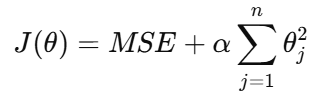

- ∑θ^2 : 가중치 제곱 합 = 패널티 항
- α : 패널티 계수

답 : alpha 작게 만들어야 함



### **4. 다음과 같이 사용해야 하는 이유는?**
___
1. 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀
2. 릿지 회귀 대신 라쏘 회귀
3. 라쏘 회귀 대신 엘라스틱넷

1번.
- 선형 회귀 비용 함수 => J(θ)=MSE
  - 가중치에 아무 제한이 없기에 과적합 문제 발생
- 규제가 있는 모델이 일반적으로 규제가 없는 모델보다 성능이 좋기 때문

2번.
- **라쏘 회귀**는 l1 페널티를 사용하여, 가중치를 완전히 0으로 만드는 경향이 있음
- **릿지 회귀**는 가중치를 작게 만들긴 하지만 0으로 만들지는 않음
- 즉, **라쏘 회귀**는 가장 중요한 가중치를 제외하고는 모두 0이 되는 희소한 모델을 만듦
  - 자동으로 특성 선택의 효과를 가지므로, 일부 특성만 실제로 유용할 것 같을 때 사용하면 좋음
  - 확신이 없다면 릿지 회귀를 사용해야 함

3번.
- 라쏘가 어떤 경우에는 불규칙하게 행동하므로, 엘라스틱넷이 라쏘보다 일반적으로 선호됨
  - 특히 피처가 서로 강하게 상관되어 있을 때 특정 하나만 선택해야 하는 경우, 비슷한 두 피처를 불안정하게 바꿔서 선택할 수 있음
- 엘라스틱넷 = Ridge + Lasso
  - 비용 함수 => J(θ)=MSE+α(L1+L2)
  - L1 → feature selection / L2 → 안정성

그래서 일반적으로 선형회귀, 릿지회귀, 라쏘회귀, 엘라스틱넷 순서로 모델 선택

| 모델         | 특징                |
| ---------- | ----------------- |
| Linear     | 규제 없음             |
| Ridge      | 안정적인 규제           |
| Lasso      | feature selection |
| ElasticNet | Ridge + Lasso     |


### **추가) 조기 종료를 사용한 배치 경사 하강법으로 iris 데이터를 활용해 소프트맥스 회귀를 구현해보세요(사이킷런은 사용하지 마세요)**


---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris # scikit-learn의 샘플 데이터 로드를 위해 import

iris = load_iris() # sample data load

In [3]:
X = iris["data"][:, (2, 3)]  # 꽃잎 길이, 꽃잎 넓이만 사용
y = iris["target"]

In [8]:
len(X)

150

In [11]:
# 1로 이루어진 열 벡터를 만들고
# 이 벡터 옆에 기존 X를 column 방향으로 붙임
np.c_[np.ones([len(X), 1]), X]

array([[1. , 1.4, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.3, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.7, 0.4],
       [1. , 1.4, 0.3],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.5, 0.1],
       [1. , 1.5, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.4, 0.1],
       [1. , 1.1, 0.1],
       [1. , 1.2, 0.2],
       [1. , 1.5, 0.4],
       [1. , 1.3, 0.4],
       [1. , 1.4, 0.3],
       [1. , 1.7, 0.3],
       [1. , 1.5, 0.3],
       [1. , 1.7, 0.2],
       [1. , 1.5, 0.4],
       [1. , 1. , 0.2],
       [1. , 1.7, 0.5],
       [1. , 1.9, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.6, 0.4],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.5, 0.4],
       [1. , 1.5, 0.1],
       [1. , 1.4, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.2, 0.2],
       [1. , 1.3, 0.2],
       [1. , 1.4, 0.1],
       [1. , 1.3, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.3, 0.3],
       [1. , 1.3

In [4]:
# 절편(bias) 추가 행렬
X_with_bias = np.c_[np.ones([len(X), 1]), X]

In [5]:
np.random.seed(2042)

In [6]:
test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

# 데이터를 랜덤으로 섞기
rnd_indices = np.random.permutation(total_size)

# train / validation / test 분리
X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

Softmax regression 이란?

- 일반 로지스틱 회귀는 0 또는 1의 두 클래스만 분류할 수 있는데, 이는 3개 이상의 클래스를 분류하고자 할 때 사용
- 소프트맥스 회귀는 먼저 각 클래스의 점수를 계산함
  - 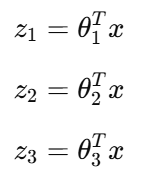
  - 이 값들을 logit 또는 score라고 함
- Softmax 함수 = 이 score를 확률로 변환
  - 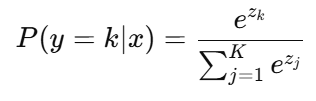

In [7]:
def to_one_hot(y):
    n_classes = y.max() + 1
    m = len(y)
    Y_one_hot = np.zeros((m, n_classes))
    Y_one_hot[np.arange(m), y] = 1
    return Y_one_hot

- One-Hot Encoding 규칙 = 해당 클래스 위치만 1, 나머지는 0
  - 예
    - y = [2,0,1]
    - 변환 후 : 0 0 1 / 1 0 0 / 0 1 0